# 🔥 Lecture 15 – Data 100, Fall 2025

Data 100, Fall 2025

[Acknowledgments Page](https://ds100.org/fa25/acks/)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import plotly.express as px
import plotly.graph_objects as go
pd.options.mode.chained_assignment = None 
warnings.simplefilter(action='ignore', category=UserWarning)
np.random.seed(42)
pd.options.display.precision = 2

## Feature Engineering

Feature engineering is the process of applying **feature functions** to generate new features for use in modeling. In this lecture, we will discuss:
* One-hot encoding
* Polynomial features

To do so, we'll work with our familiar `tips` dataset.

In [2]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### One-Hot Encoding

One-hot encoding is a feature engineering technique to generate numeric feature from categorical data. For example, we can use one-hot encoding to incorporate the day of the week as an input into a regression model.

![](ohe.png)

Suppose we want to use a design matrix of three features – the `total_bill`, `size`, and `day` – to predict the tip. 

In [3]:
X_raw = tips[["total_bill", "size", "day"]]
y = tips["tip"]

Because `day` is non-numeric, we will apply one-hot encoding before fitting a model.

The `OneHotEncoder` class of `sklearn` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder.get_feature_names_out)) offers a quick way to perform one-hot encoding. You will explore its use in detail in Lab 7. 

For now, recognize that we follow a very similar workflow to when we were working with the `LinearRegression` class: 

1. We initialize a `OneHotEncoder` object.

2. We fit the object to our data.

3. We use `.transform` to apply the fitted encoder and generate the one-hot encoded columns.

In [4]:
from sklearn.preprocessing import OneHotEncoder

# 1. Initialize a OneHotEncoder object
ohe = OneHotEncoder()

# 2. Fit the encoder
ohe.fit(tips[["day"]])
ohe

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [5]:
# .get_feature_names_out() method returns the names of the unique values
# the encoder was trained on. Notice how the names are constructed:
# {name of column}_{unique value in the column}
ohe.get_feature_names_out()

array(['day_Fri', 'day_Sat', 'day_Sun', 'day_Thur'], dtype=object)

In [6]:
# .transform() converts a list of sub-lists into a one-hot encoded array.
# Each sub-list represents the features of an observation. 
# Notice we get back a sparse matrix, a special kind of matrix with many zeros.
ohe.transform([['Sat'], ['Sat'], ['Fri']])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (3, 4)>

In [7]:
# .toarray() is needed to convert the sparse matrix to a dense matrix.
ohe.transform([['Sat'], ['Sat'], ['Fri']]).toarray()

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.]])

In [8]:
# This gives an error! The encoder has never seen 'Funday' before.
# ohe.transform([['Funday']])

In [9]:
# 3. Use the encoder to transform the raw "day" feature 
encoded_day = ohe.transform(tips[["day"]]).toarray()

print("The first 5 rows of the one-hot encoded matrix:")
encoded_day[:5, :]

The first 5 rows of the one-hot encoded matrix:


array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]])

In [10]:
# Convert the matrix into a one-hot encoded dataframe
encoded_day_df = pd.DataFrame(encoded_day, columns=ohe.get_feature_names_out())
encoded_day_df.head()

,day_Fri,day_Sat,day_Sun,day_Thur
0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


The `OneHotEncoder` has converted the categorical `day` feature into four numeric features! Recall that the `tips` dataset only included data for Thursday through Sunday, which is why only four days of the week appear. 

Let's join this one-hot encoding to the original data to form our featurized design matrix. We drop the original `day` column so our design matrix only includes numeric values.

In [11]:
# Join the one-hot encoded features to the original data, and drop
# the original categorical column.
X = X_raw.join(encoded_day_df).drop(columns="day")

X.head()

,total_bill,size,day_Fri,day_Sat,day_Sun,day_Thur
0,16.99,2,0.0,0.0,1.0,0.0
1,10.34,3,0.0,0.0,1.0,0.0
2,21.01,3,0.0,0.0,1.0,0.0
3,23.68,2,0.0,0.0,1.0,0.0
4,24.59,4,0.0,0.0,1.0,0.0


Now, we can use `sklearn`'s `LinearRegression` class to fit a model to this design matrix.

In [12]:
from sklearn.linear_model import LinearRegression

# For now, we tell sklearn to not add an additional bias column. 
# Otherwise, the bias column and one-hot encoded columns will be 
# linearly dependent, and XTX will not be invertible.
ohe_model = LinearRegression(fit_intercept=False) 

ohe_model.fit(X, y)

pd.DataFrame({
  "Feature": X.columns, 
  "Model Coefficient": ohe_model.coef_
}).set_index("Feature")

,Model Coefficient
Feature,
total_bill,0.09
size,0.19
day_Fri,0.75
day_Sat,0.62
day_Sun,0.73
day_Thur,0.67


In [13]:
# Notice the intercept is set to 0, so it does not affect the model.
# This is because we set fit_intercept=False.
ohe_model.intercept_

0.0

In [14]:
# This time, let's see what happens when we include an intercept. 
ohe_model2 = LinearRegression(fit_intercept=True) 

# This code does the same as above.
# Including an intercept is the LinearRegression default.
# ohe_model2 = LinearRegression() 

# Remove the "day_Fri" column as the reference level, so that our one-hot 
# encoded columns are not linearly dependent.
new_X = X.drop('day_Fri', axis=1)

display(new_X.head())

,total_bill,size,day_Sat,day_Sun,day_Thur
0,16.99,2,0.0,1.0,0.0
1,10.34,3,0.0,1.0,0.0
2,21.01,3,0.0,1.0,0.0
3,23.68,2,0.0,1.0,0.0
4,24.59,4,0.0,1.0,0.0


In [15]:
# ohe_model2 will add a bias column in the background, 
# since we set fit_intercept=True earlier.
ohe_model2.fit(new_X, y)

pd.DataFrame({
  "Feature": np.append('Intercept', new_X.columns), 
  "Model Coefficient": np.append(ohe_model2.intercept_, ohe_model2.coef_)
}).set_index("Feature")

,Model Coefficient
Feature,
Intercept,0.75
total_bill,0.09
size,0.19
day_Sat,-0.12
day_Sun,-0.01
day_Thur,-0.08


Note that the two models above will generate identical predictions. The only difference is the **interpretability** of the coefficients.

We could have also had one-hot encoder object drop the reference column earlier in the pipeline:

In [16]:
# Initialize a OneHotEncoder object.
# This time, we will drop the first column of the one-hot encoded columns.
# This is the only change from the previous example!
ohe2 = OneHotEncoder(drop='first')

# Fit the encoder
ohe2.fit(tips[["day"]])

# Use the encoder to transform the raw "day" feature
encoded_day = ohe2.transform(tips[["day"]]).toarray()

encoded_day_df = pd.DataFrame(encoded_day, columns=ohe2.get_feature_names_out())

encoded_day_df.head()

,day_Sat,day_Sun,day_Thur
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


### Bonus: Advanced Feature Engineering Pipelines in Scikit Learn
You can use the scikit learn `Pipeline` class to define sophisticated feature engineering pipelines that combine different transformations that are all fit at once.

A pipeline is a sequence of transformations and models that are composed to form a new model. It is implemented as a list of  ("name", model/transformation) tuples.  Here we have a feature engineering stage followed by a linear model. The feature engineering stage uses a `ColumnTransformer` that applies named transformations to selected columns.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures

pl = Pipeline([
    ("Feature Engineering", 
     ColumnTransformer(  
         [("OHE", OneHotEncoder(), ["day"]),
         ("Polynomial", PolynomialFeatures(4), ['total_bill'])], 
        remainder="passthrough")), 
    ("Linear Model", LinearRegression()) # Linear Model
]) 
pl

,steps,"[('Feature Engineering', ...), ('Linear Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OHE', ...), ('Polynomial', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
pl.fit(X_raw, y)

,steps,"[('Feature Engineering', ...), ('Linear Model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('OHE', ...), ('Polynomial', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


All the features:

In [19]:
pl['Feature Engineering'].get_feature_names_out()

array(['OHE__day_Fri', 'OHE__day_Sat', 'OHE__day_Sun', 'OHE__day_Thur',
       'Polynomial__1', 'Polynomial__total_bill',
       'Polynomial__total_bill^2', 'Polynomial__total_bill^3',
       'Polynomial__total_bill^4', 'remainder__size'], dtype=object)

In [20]:
tips["predicted"] = pl.predict(X_raw)
tips

,total_bill,tip,sex,smoker,day,time,size,predicted
0,16.99,1.01,Female,No,Sun,Dinner,2,2.78
1,10.34,1.66,Male,No,Sun,Dinner,3,2.11
2,21.01,3.50,Male,No,Sun,Dinner,3,3.49
3,23.68,3.31,Male,No,Sun,Dinner,2,3.54
4,24.59,3.61,Female,No,Sun,Dinner,4,4.00
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,3.78
240,27.18,2.00,Female,Yes,Sat,Dinner,2,3.54
241,22.67,2.00,Male,Yes,Sat,Dinner,2,3.28
242,17.82,1.75,Male,No,Sat,Dinner,2,2.72


<br/><br/><br/>
**Return to Lecture**

<br/><br/><br/>

### Polynomial Features

Consider the `vehicles` dataset, which includes information about cars.

In [21]:
vehicles = sns.load_dataset("mpg")

vehicles = vehicles.dropna().rename(columns = {"horsepower": "hp"}).sort_values("hp")

vehicles.head()

,mpg,cylinders,displacement,hp,weight,acceleration,model_year,origin,name
19,26.0,4,97.0,46.0,1835,20.5,70,europe,volkswagen 1131 deluxe sedan
102,26.0,4,97.0,46.0,1950,21.0,73,europe,volkswagen super beetle
326,43.4,4,90.0,48.0,2335,23.7,80,europe,vw dasher (diesel)
325,44.3,4,90.0,48.0,2085,21.7,80,europe,vw rabbit c (diesel)
244,43.1,4,90.0,48.0,1985,21.5,78,europe,volkswagen rabbit custom diesel


Suppose we want to use the `hp` (horsepower) of a car to predict its `mpg` (gas mileage in miles per gallon). If we visualize the relationship between these two variables, we see a non-linear curvature. Fitting a linear model to these variables results in a high (poor) value of RMSE. 

$$\hat{y} = \theta_0 + \theta_1 (\text{hp})$$

In [22]:
X = vehicles[["hp"]]
y = vehicles["mpg"]

hp_model = LinearRegression()
hp_model.fit(X, y)
hp_model_predictions = hp_model.predict(X)

print(f"MSE of model with (hp) feature: {np.mean((y-hp_model_predictions)**2)}")

fig = px.scatter(vehicles, x="hp", y="mpg", width=800, height=600)
fig.add_trace(go.Scatter(x=vehicles["hp"], y=hp_model_predictions,
                         mode="lines", name="Linear Prediction"))
# sns.scatterplot(data=vehicles, x="hp", y="mpg")
# plt.plot(vehicles["hp"], hp_model_predictions, c="tab:red");



MSE of model with (hp) feature: 23.943662938603104


To capture the non-linear relationship between the variables, we can introduce a non-linear feature: `hp` squared. Our new model is:

$$\hat{y} = \theta_0 + \theta_1 (\text{hp}) + \theta_2 (\text{hp}^2)$$

In [23]:
X = vehicles[["hp"]]
X.loc[:, "hp^2"] = vehicles["hp"]**2

hp2_model = LinearRegression()
hp2_model.fit(X, y)
hp2_model_predictions = hp2_model.predict(X)


print(f"MSE of model with (hp^2) feature: {np.mean((y-hp2_model_predictions)**2)}")

fig = px.scatter(vehicles, x="hp", y="mpg", width=800, height=600)
fig.add_trace(go.Scatter(x=vehicles["hp"], y=hp2_model_predictions,
                         mode="lines", name="Quadratic Prediction"))
# sns.scatterplot(data=vehicles, x="hp", y="mpg")
# plt.plot(vehicles["hp"], hp2_model_predictions, c="tab:red");


MSE of model with (hp^2) feature: 18.98476890761722


What if we take things further and add even *more* polynomial features?

The cell below fits models of increasing complexity and computes their MSEs.

In [24]:
def mse(predictions, observations):
    return np.mean((observations - predictions)**2)

# Add hp^3 and hp^4 as features to the data
X["hp^3"] = vehicles["hp"]**3
X["hp^4"] = vehicles["hp"]**4

# Fit a model with order 3
hp3_model = LinearRegression()
hp3_model.fit(X[["hp", "hp^2", "hp^3"]], vehicles["mpg"])
hp3_model_predictions = hp3_model.predict(X[["hp", "hp^2", "hp^3"]])

# Fit a model with order 4
hp4_model = LinearRegression()
hp4_model.fit(X[["hp", "hp^2", "hp^3", "hp^4"]], vehicles["mpg"])
hp4_model_predictions = hp4_model.predict(X[["hp", "hp^2", "hp^3", "hp^4"]])

In [25]:
fig = px.scatter(vehicles, x="hp", y="mpg", width=800, height=600)
fig.add_trace(go.Scatter(
    x=vehicles["hp"], y=hp_model_predictions, mode="lines", 
    name=f"HP MSE={np.round(mse(vehicles['mpg'], hp_model_predictions),3)}"))
fig.add_trace(go.Scatter(
    x=vehicles["hp"], y=hp2_model_predictions, mode="lines", 
    name=f"HP^2 MSE={np.round(mse(vehicles['mpg'], hp2_model_predictions),3)}"))
fig.add_trace(go.Scatter(
    x=vehicles["hp"], y=hp3_model_predictions, mode="lines", 
    name=f"HP^3 MSE={np.round(mse(vehicles['mpg'], hp3_model_predictions),3)}"))
fig.add_trace(go.Scatter(
    x=vehicles["hp"], y=hp4_model_predictions, mode="lines", 
    name=f"HP^4 MSE={np.round(mse(vehicles['mpg'], hp4_model_predictions),3)}"))

Visualizing differently:

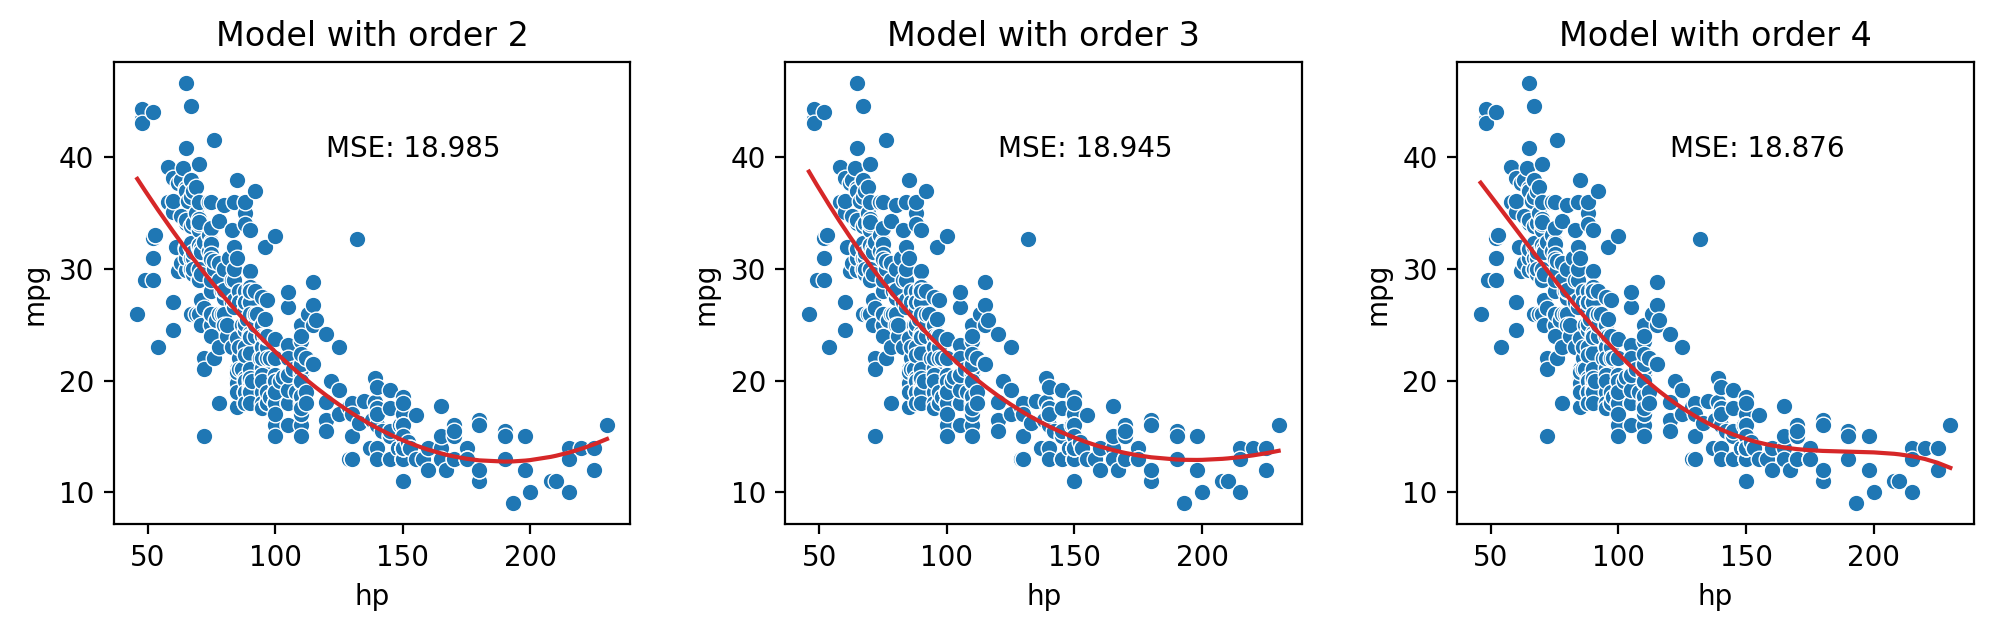

In [26]:
# Plot the models' predictions
fig, ax = plt.subplots(1, 3, dpi=200, figsize=(12, 3))

predictions_dict = {0:hp2_model_predictions, 1:hp3_model_predictions, 2:hp4_model_predictions}

for i in predictions_dict:
    ax[i].scatter(vehicles["hp"], vehicles["mpg"], edgecolor="white", lw=0.5)
    ax[i].plot(vehicles["hp"], predictions_dict[i], "tab:red")
    ax[i].set_title(f"Model with order {i+2}")
    ax[i].set_xlabel("hp")
    ax[i].set_ylabel("mpg")
    ax[i].annotate(f"MSE: {np.round(mse(vehicles['mpg'], predictions_dict[i]), 3)}", (120, 40))

plt.subplots_adjust(wspace=0.3);

## Complexity and Overfitting

What we saw above was the phenomenon of **model complexity** – as we add additional features to the design matrix, the model becomes increasingly *complex*. Models with higher complexity have lower values of training error. Intuitively, this makes sense: with more features at its disposal, the model can match the observations in the trainining data more and more closely. 

We can run an experiment to see this in action. In the cell below, we fit many models of progressively higher complexity, then plot the MSE of predictions on the training set. The code used (specifically, the `Pipeline` and `PolynomialFeatures` functions of `sklearn`) is out of scope.

The **order** of a polynomial model is the highest power of any term in the model. An order 0 model takes the form $\hat{y} = \theta_0$, while an order 4 model takes the form $\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \theta_4 x^4$.

[0.]
[ 0.         -0.15784473]
[ 0.         -0.46618963  0.00123054]
[ 0.00000000e+00 -5.68850128e-01  2.07901126e-03 -2.14662591e-06]
[ 0.00000000e+00 -7.66721254e-02 -4.34464071e-03  3.24511554e-05
 -6.53036309e-08]
[ 0.00000000e+00  3.70010383e+00 -7.14239929e-02  5.93107892e-04
 -2.28107356e-06  3.32954911e-09]
[ 0.00000000e+00  1.44682182e-04  6.49865722e-03 -2.36791676e-04
  2.45462812e-06 -1.04648265e-08  1.60999470e-11]
[ 0.00000000e+00 -3.36614779e-08 -2.51512804e-06 -9.07909631e-05
  1.10789246e-06 -4.49999526e-09  4.16365602e-12  7.57895672e-15]
[ 0.00000000e+00 -1.00713775e-11 -7.99168233e-10 -4.91973612e-08
 -1.68574938e-06  3.04883800e-08 -2.14447340e-10  6.83323254e-13
 -8.23761555e-16]


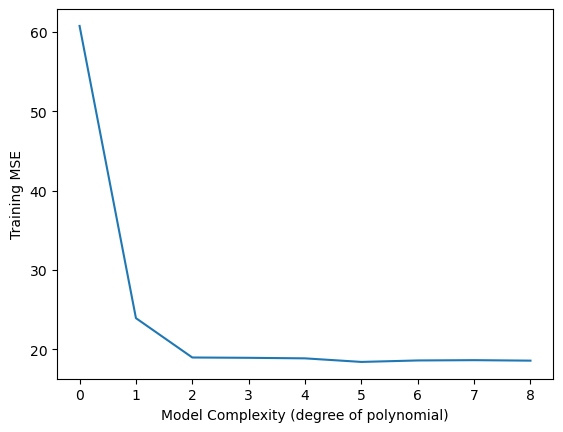

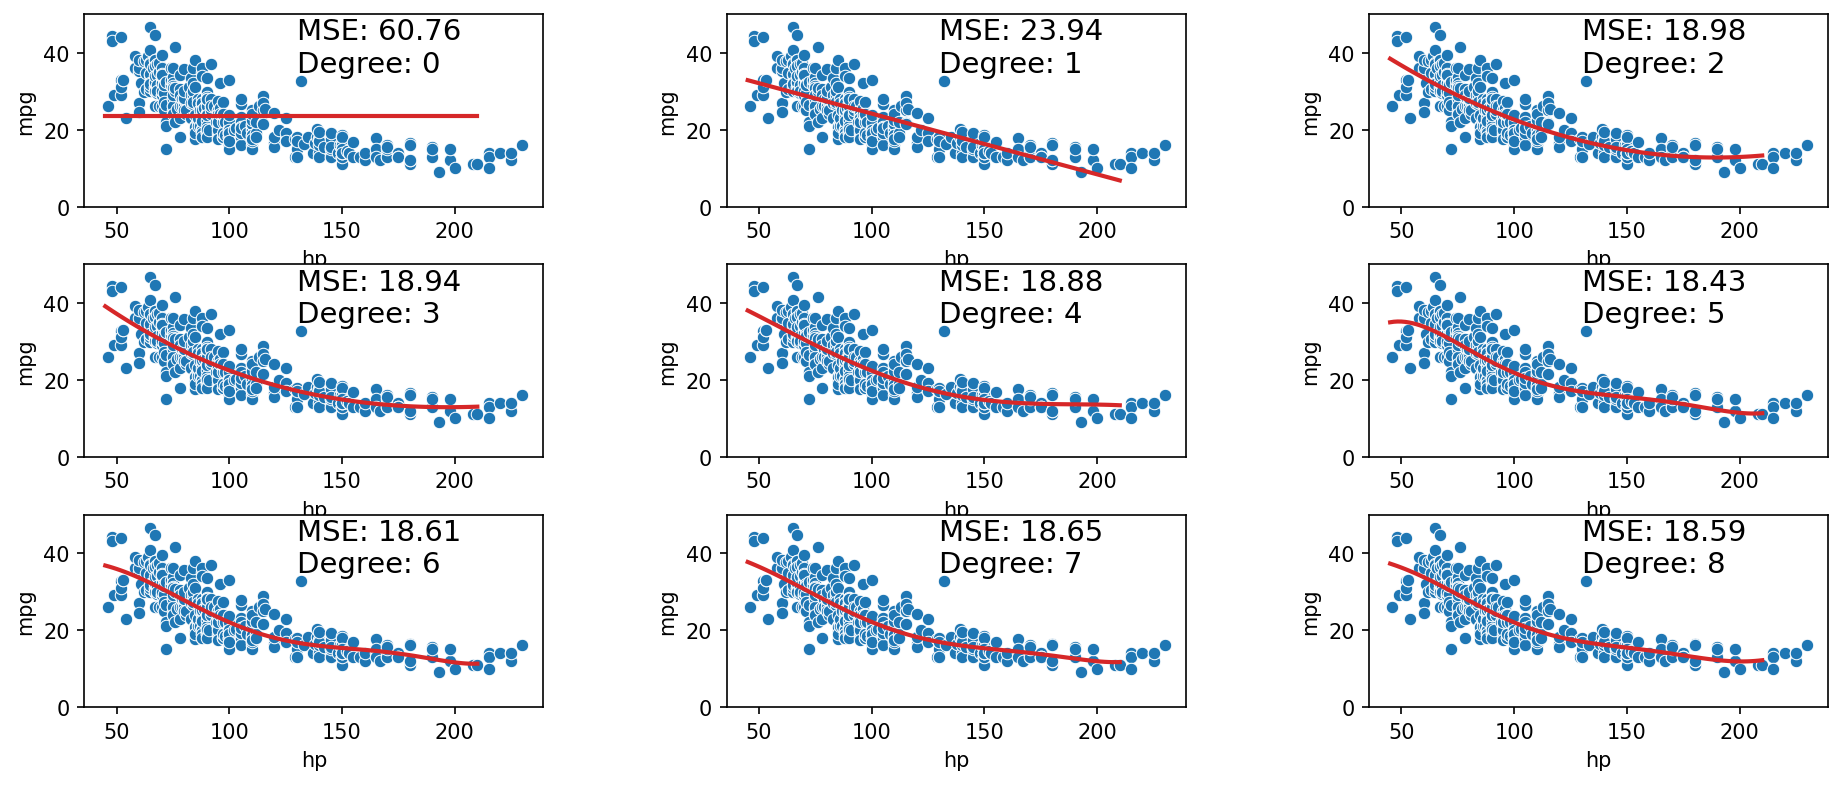

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

MAX_DEGREE = 9

def fit_model_dataset(degree, dataset):
    pipelined_model = Pipeline([
            ('polynomial_transformation', PolynomialFeatures(degree)),
            ('linear_regression', LinearRegression())    
        ])

    pipelined_model.fit(dataset[["hp"]], dataset["mpg"])
    return mse(dataset['mpg'], pipelined_model.predict(dataset[["hp"]]))

errors = [fit_model_dataset(degree, vehicles) for degree in range(0, MAX_DEGREE)]
MSEs_and_k = pd.DataFrame({"k": range(0, MAX_DEGREE), "MSE": errors})

plt.plot(range(0, MAX_DEGREE), errors)
plt.xlabel("Model Complexity (degree of polynomial)")
plt.ylabel("Training MSE");

def plot_degree_k_model(k, MSEs_and_k, axs):
    pipelined_model = Pipeline([
        ('poly_transform', PolynomialFeatures(degree = k)),
        ('regression', LinearRegression(fit_intercept = True))    
    ])
    pipelined_model.fit(vehicles[["hp"]], vehicles["mpg"])

    print(pipelined_model.named_steps['regression'].coef_)
    
    row = k // 3
    col = k % 3
    ax = axs[row, col]
    
    sns.scatterplot(data=vehicles, x='hp', y='mpg', ax=ax)
    
    x_range = np.linspace(45, 210, 100).reshape(-1, 1)
    ax.plot(x_range, pipelined_model.predict(pd.DataFrame(x_range, columns=['hp'])), c='tab:red', linewidth=2)
    
    ax.set_ylim((0, 50))
    mse_str = f"MSE: {MSEs_and_k.loc[k, 'MSE']:.4}\nDegree: {k}"
    ax.text(130, 35, mse_str, dict(size=14))

fig = plt.figure(figsize=(15, 6), dpi=150)
axs = fig.subplots(nrows=3, ncols=3)

for k in range(MAX_DEGREE):
    plot_degree_k_model(k, MSEs_and_k, axs)
fig.subplots_adjust(wspace=0.4, hspace=0.3)

As the model increases in polynomial degree (that is, it increases in complexity), the training MSE decreases, plateauing at roughly ~18.

In fact, it is a mathematical fact that if we create a polynomial model with degree $n-1$, we can *perfectly* model a set of $n$ points. For example, a set of 5 points can be perfectly modeled by a degree 4 model.

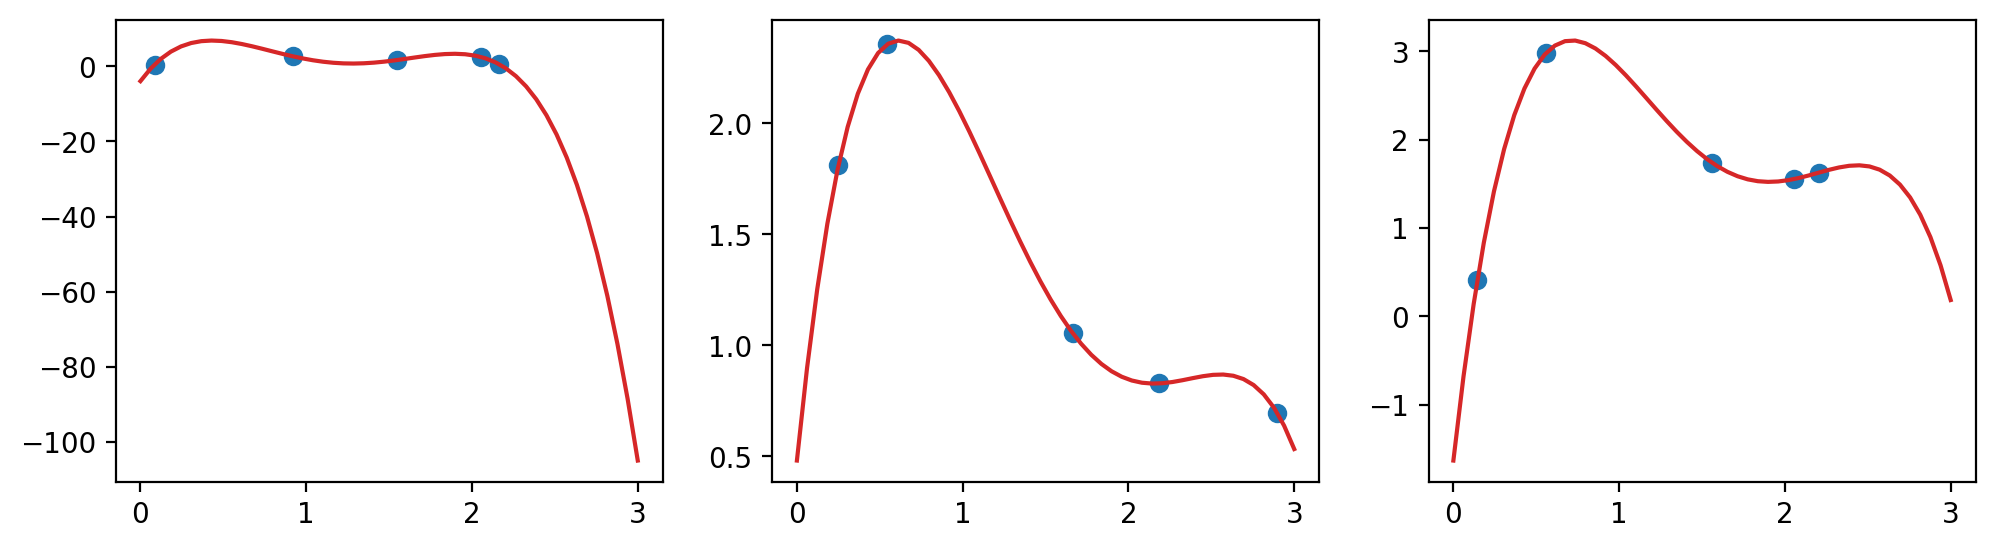

In [28]:
np.random.seed(101)

fig, ax = plt.subplots(1, 3, dpi=200, figsize=(12, 3))

for i in range(0, 3):
    points = 3*np.random.uniform(size=(5, 2))

    polynomial_model = Pipeline([
                ('polynomial_transformation', PolynomialFeatures(4)),
                ('linear_regression', LinearRegression())    
            ])

    polynomial_model.fit(points[:, [0]], points[:, 1])

    ax[i].scatter(points[:, 0], points[:, 1])

    xs = np.linspace(0, 3)
    ax[i].plot(xs, polynomial_model.predict(xs[:, np.newaxis]), c="tab:red");

You may be tempted to always design models with high polynomial degree – after all, we know that we could theoretically achieve perfect predictions by creating a model with enough polynomial features. 

It turns out that the examples we looked at above represent a somewhat artificial scenario: we trained our model on all the data we had available, then used the model to make predictions on this very same dataset. A more realistic situation is when we wish to apply our model on unseen data – that is, datapoints that it did not encounter during the model fitting process. 

Suppose we obtain a random sample of 6 datapoints from our population of vehicle data. We want to train a model on these 6 points and use it to make predictions on unseen data (perhaps cars for which we don't already know the true `mpg`). 

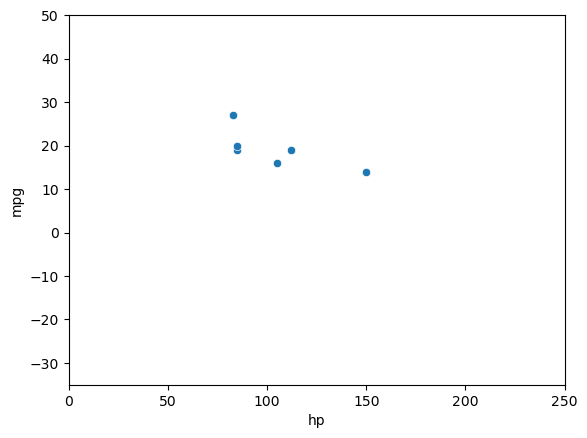

In [29]:
np.random.seed(100)

sample_6 = vehicles.sample(6)

sns.scatterplot(data=sample_6, x="hp", y="mpg")
plt.ylim(-35, 50)
plt.xlim(0, 250);

If we design a model with polynomial degree 5, we can make perfect predictions on this sample of training data.

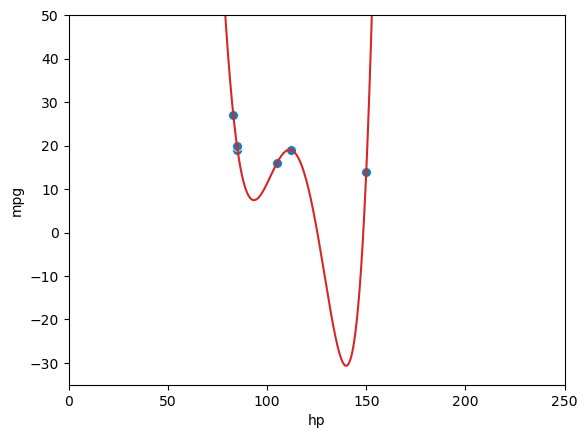

In [30]:
degree_5_model = Pipeline([
                ('polynomial_transformation', PolynomialFeatures(5)),
                ('linear_regression', LinearRegression())    
            ])

degree_5_model.fit(sample_6[["hp"]], sample_6["mpg"])
xs = np.linspace(0, 250, 1000)
degree_5_model_predictions = degree_5_model.predict(xs[:, np.newaxis])

plt.plot(xs, degree_5_model_predictions, c="tab:red")
sns.scatterplot(data=sample_6, x="hp", y="mpg", s=50)
plt.ylim(-35, 50)
plt.xlim(0, 250);

However, when we reapply this fitted model to the full population of data, it fails to capture the major trends of the dataset.

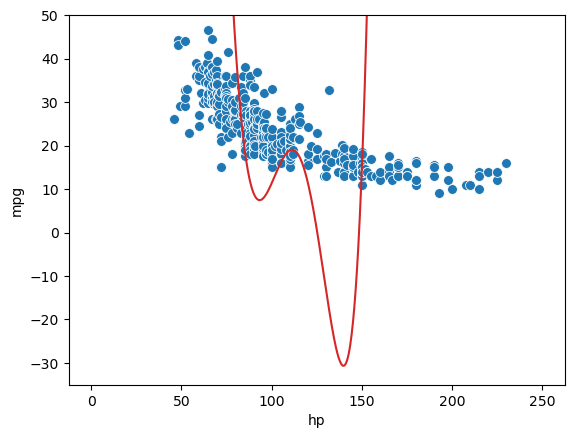

In [31]:
plt.plot(xs, degree_5_model_predictions, c="tab:red")
sns.scatterplot(data=vehicles, x="hp", y="mpg", s=50)
plt.ylim(-35, 50);

The model has **overfit** to the data used to train it. It has essentially "memorized" the six datapoints used during model fitting, and does not generalize well to new data. 

Complex models tend to be more sensitive to the data used to train them. The **variance** of a model refers to its tendency to vary depending on the training data used during model fitting. It turns out that our degree-5 model has very high model variance. If we randomly sample new sets of datapoints to use in training, the model varies erratically. 

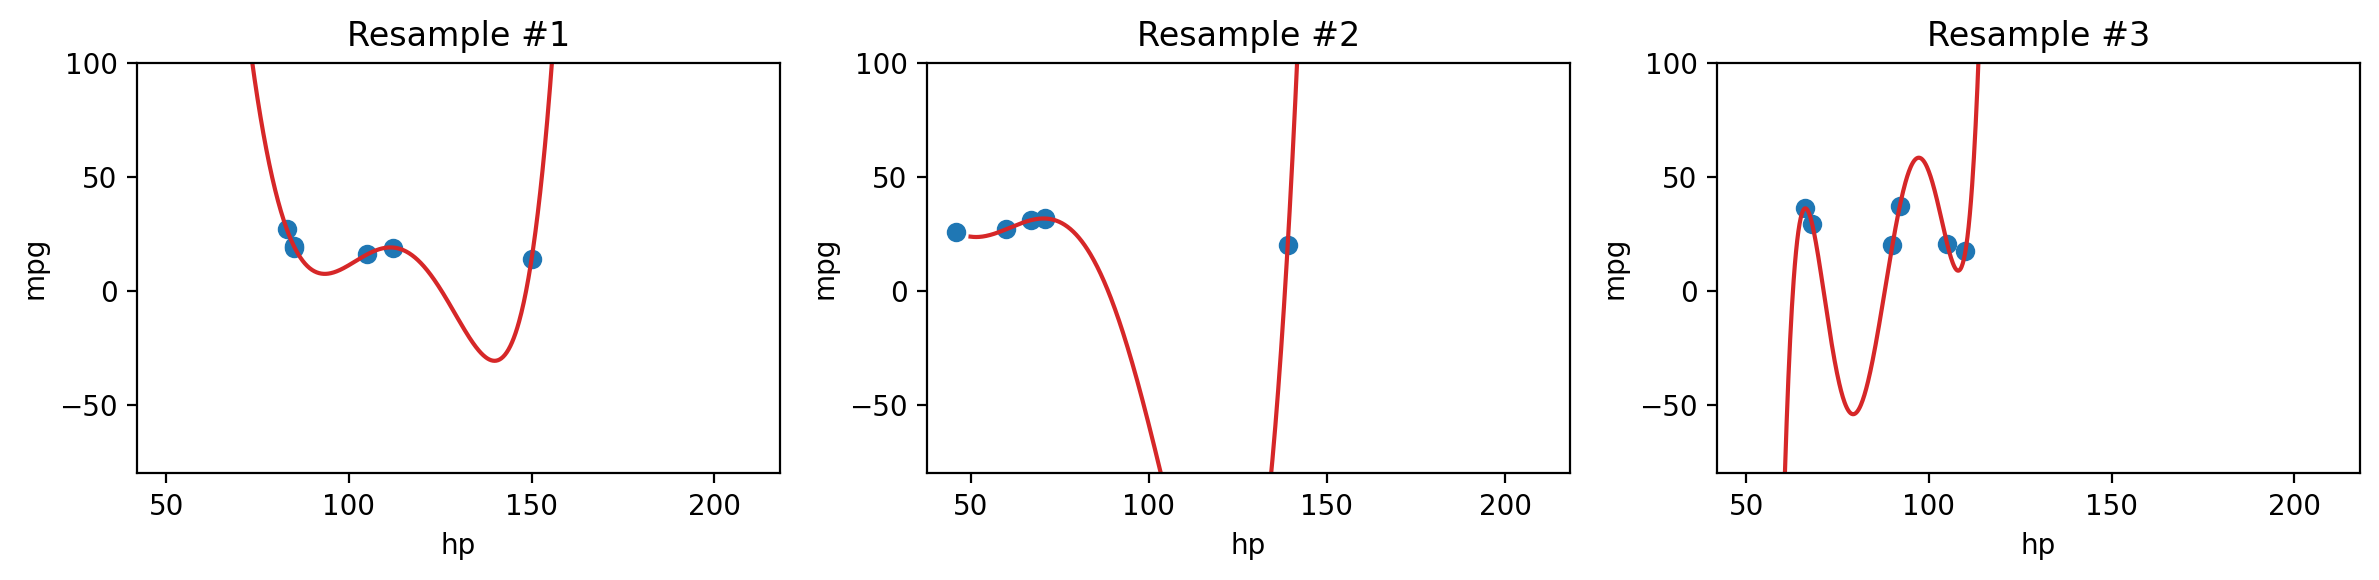

In [32]:
np.random.seed(100)

fig, ax = plt.subplots(1, 3, dpi=200, figsize=(12, 3))

for i in range(0, 3):
    sample = vehicles.sample(6)

    polynomial_model = Pipeline([
                ('polynomial_transformation', PolynomialFeatures(5)),
                ('linear_regression', LinearRegression())    
            ])

    polynomial_model.fit(sample[["hp"]], sample["mpg"])

    ax[i].scatter(sample[["hp"]], sample["mpg"])

    xs = np.linspace(50, 210, 1000)
    ax[i].plot(xs, polynomial_model.predict(xs[:, np.newaxis]), c="tab:red")
    ax[i].set_ylim(-80, 100)
    ax[i].set_xlabel("hp")
    ax[i].set_ylabel("mpg")
    ax[i].set_title(f"Resample #{i+1}")
    
fig.tight_layout();

Visualizing differently:

In [33]:
np.random.seed(16)

fig = px.scatter(vehicles, x="hp", y="mpg", width=800, height=600)

for i in range(0, 3):
    sample = vehicles.sample(6).sort_values("hp")
    
    polynomial_model = Pipeline([
                ('polynomial_transformation', PolynomialFeatures(5)),
                ('linear_regression', LinearRegression())    
            ])

    polynomial_model.fit(sample[["hp"]], sample["mpg"])
    
    name = f"Sample {i+1}"
    fig.add_trace(go.Scatter(x=sample["hp"], y=sample["mpg"], 
        name=name, legendgroup=name, mode="markers", showlegend=False,
        marker_size=16,
        marker_color=px.colors.qualitative.Plotly[i+1]))
    xs = np.linspace(10, 250, 1000)
    fig.add_trace(go.Scatter(x=xs, 
        y=polynomial_model.predict(xs[:, np.newaxis]),
        name=name, legendgroup=name, mode="lines",
        line_color=px.colors.qualitative.Plotly[i+1]))

fig.update_yaxes(range=[0, 50])